In [1]:
import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

city_data_vault = {}

def calculate_orientation_entropy(bearings, num_bins=36):
    if not bearings:
        return 0.0
    bins = np.arange(0, 360 + 360 / num_bins, 360 / num_bins)
    counts, _ = np.histogram(bearings, bins=bins)
    prob = counts / counts.sum()
    prob = prob[prob > 0]
    entropy = -np.sum(prob * np.log(prob))
    return entropy

def generate_styled_map(zone_id, coords, label, dist=3000):
    G = ox.graph_from_point(coords, dist=dist, network_type='drive')
    G_proj = ox.project_graph(G)
    
    fig, ax = ox.plot_graph(G_proj, 
                            node_size=5,          
                            node_color='#FF8C00', 
                            edge_color='white',   
                            edge_linewidth=0.6,   
                            bgcolor='black',      
                            show=True, 
                            close=False)
    
    G = ox.add_edge_bearings(G)
    bearings = [d['bearing'] for u, v, k, d in G.edges(keys=True, data=True) if 'bearing' in d]
    entropy_val = calculate_orientation_entropy(bearings)
    
    fig_rose, ax_rose = ox.plot_orientation(G, 
                                            num_bins=36, 
                                            figsize=(5, 5),
                                            color='#003366',    
                                            edgecolor='k',      
                                            linewidth=0.5)
    plt.show()
    
    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)
    stats = ox.basic_stats(G_proj)
    
    try:
        area_km2 = nodes_gdf.union_all().convex_hull.area / 1_000_000
    except AttributeError:
        area_km2 = nodes_gdf.unary_union.convex_hull.area / 1_000_000
        
    intersections = len([n for n, deg in G_proj.degree() if deg > 2])
    intersection_density = intersections / area_km2 if area_km2 > 0 else 0
    
    centrality_dict = nx.degree_centrality(G_proj)
    avg_centrality = np.mean(list(centrality_dict.values()))

    city_data_vault[label] = {
        'bearings': bearings,
        'orientation_entropy': entropy_val,
        'avg_area': area_km2,  
        'intersection_density': intersection_density,  
        'avg_edge_length': stats.get('street_length_avg', 0),  
        'avg_circuity': stats.get('circuity_avg', 0), 
        'avg_degree_centrality': avg_centrality 
    }

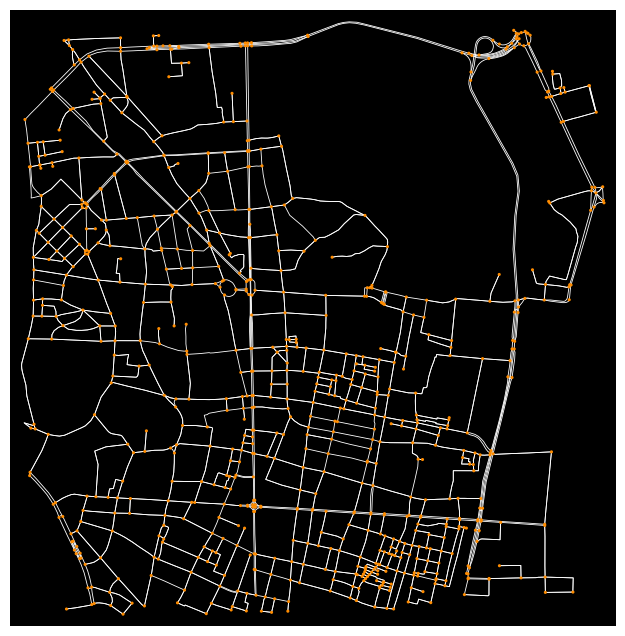

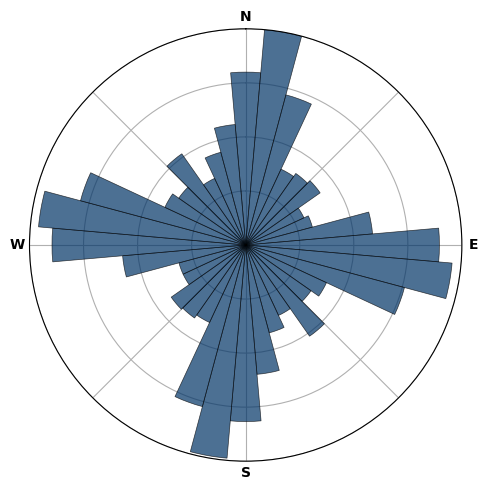

In [2]:
generate_styled_map("01", (32.058, 118.785), "Xuanwu (City Core)", dist=2500)              # 玄武城市核心

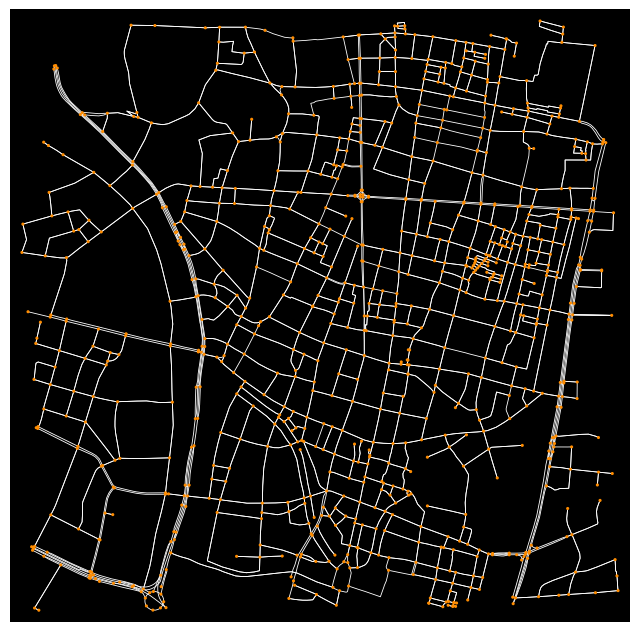

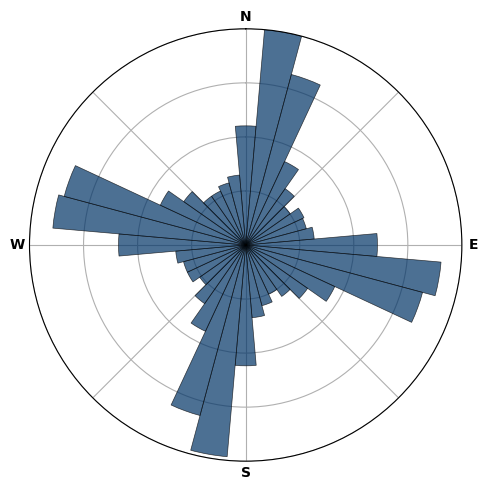

In [3]:
generate_styled_map("02", (32.035, 118.775), "Qinhuai (Old Town)", dist=2500)             # 秦淮老城区

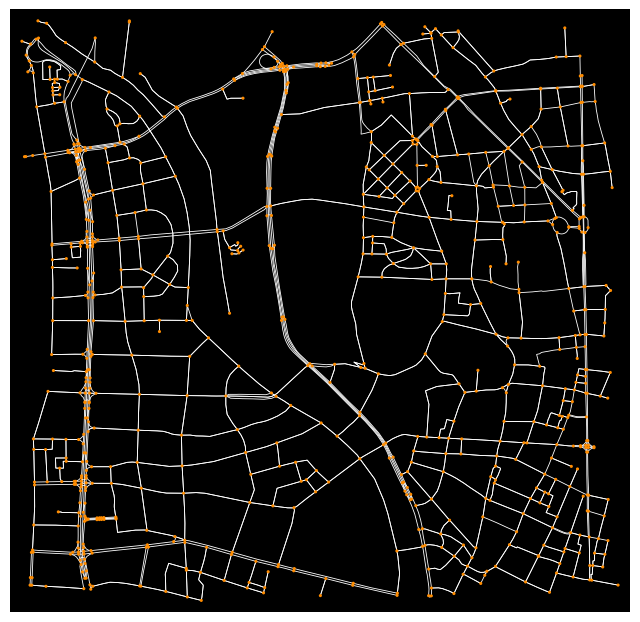

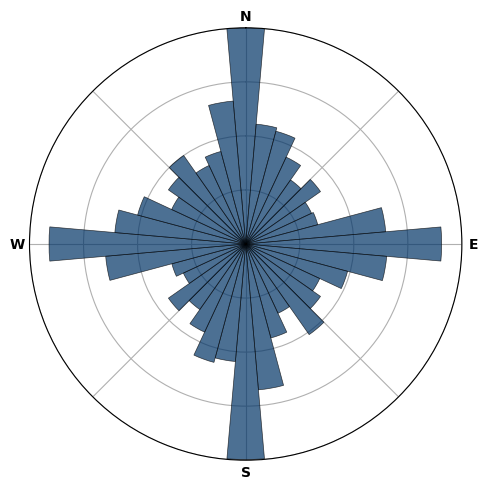

In [4]:
generate_styled_map("03", (32.055, 118.755), "Gulou (Business Core)", dist=2500)          # 鼓楼商务核心

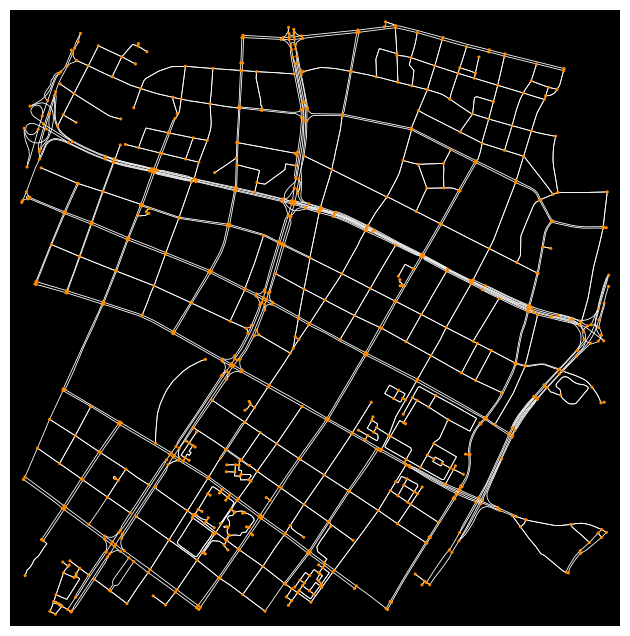

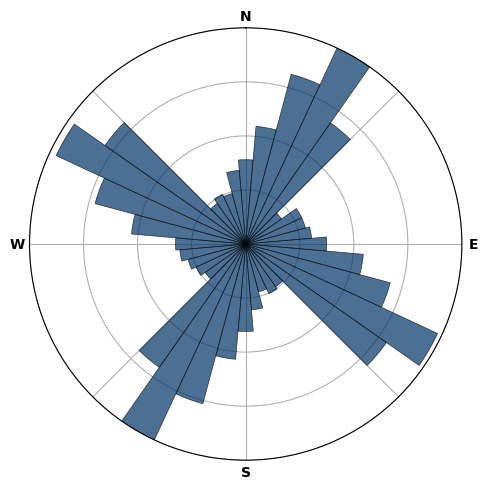

In [5]:
generate_styled_map("04", (32.015, 118.735), "Jianye (Hexi CBD)", dist=2500)              # 建邺河西CBD

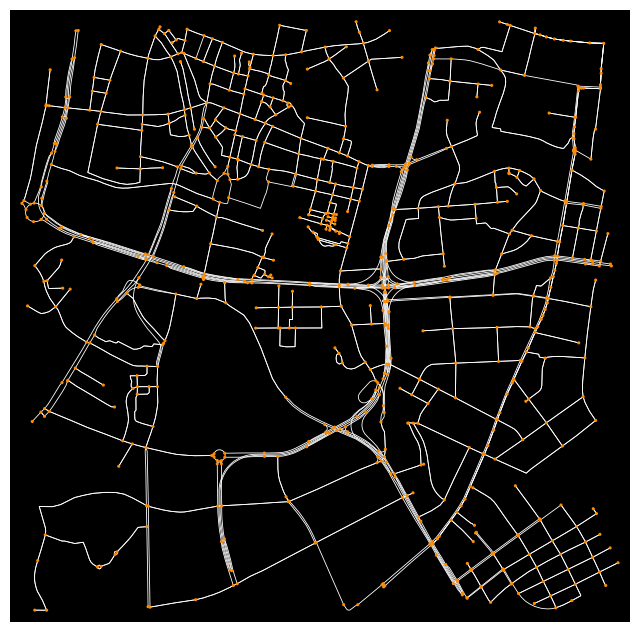

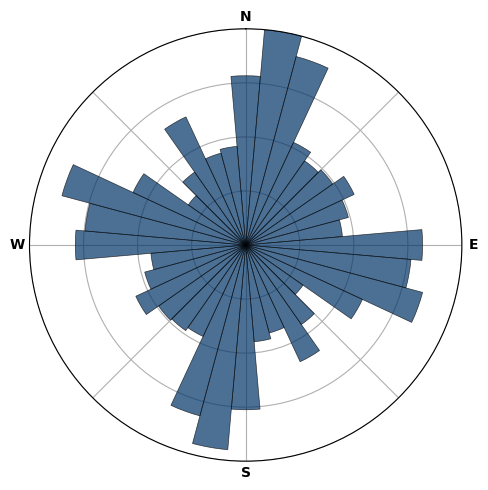

In [6]:
generate_styled_map("05", (32.005, 118.785), "Yuhuatai (Tech Zone)", dist=2500)          # 雨花台科技区

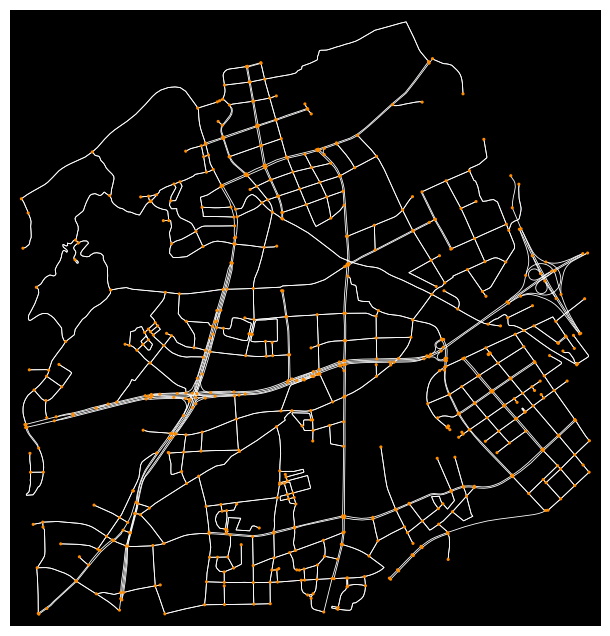

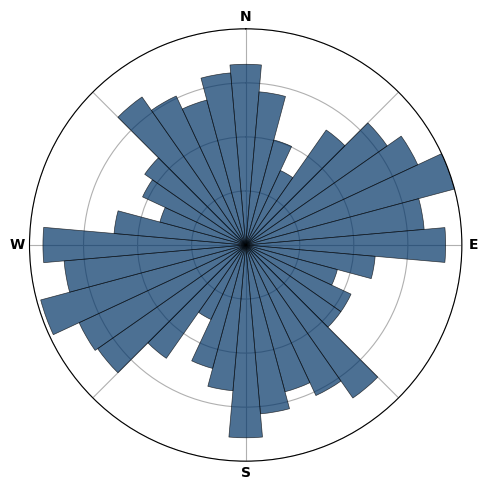

In [7]:
generate_styled_map("06", (32.125, 118.825), "Qixia (Economic Zone)", dist=3000)          # 栖霞经开区

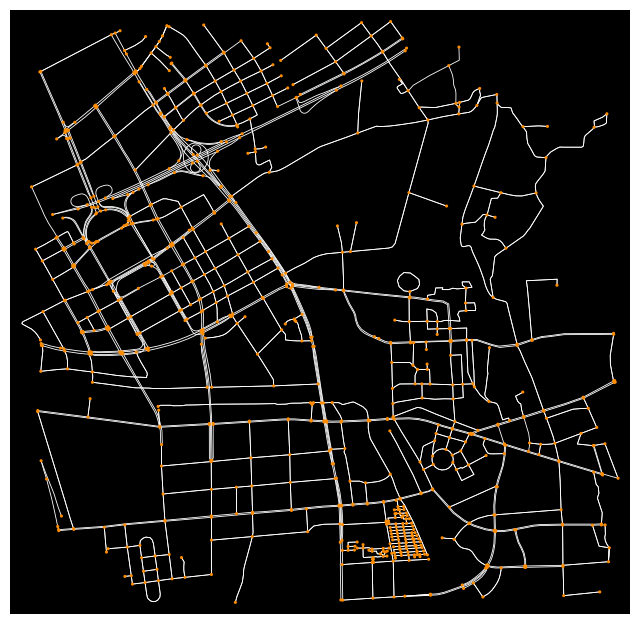

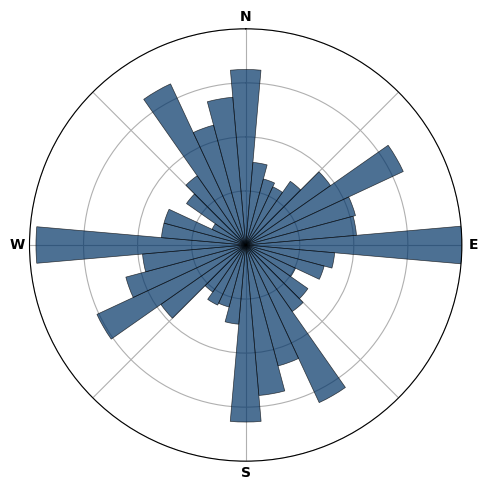

In [8]:
generate_styled_map("07", (31.965, 118.815), "Jiangning (Jinchun Rd)", dist=3000)        # 江宁核心

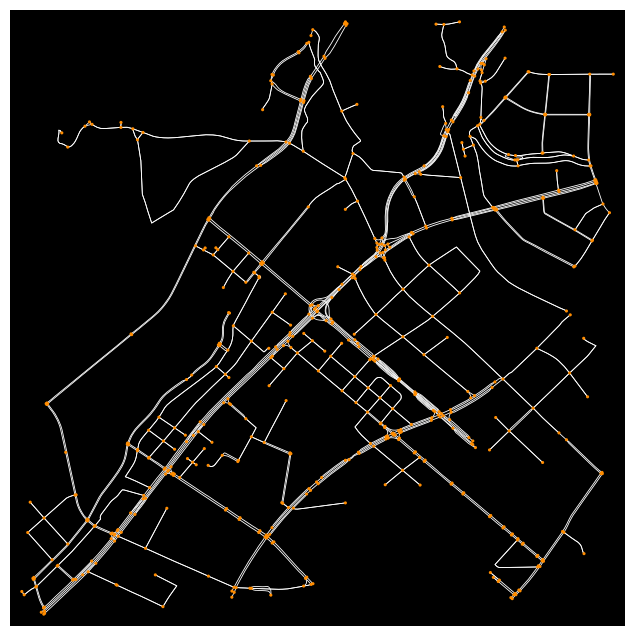

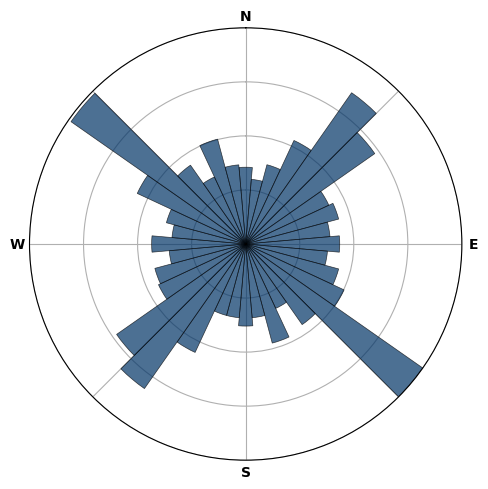

In [9]:
generate_styled_map("08", (32.105, 118.675), "Pukou (Jiangpu New City)", dist=3000)       # 浦口江浦新城

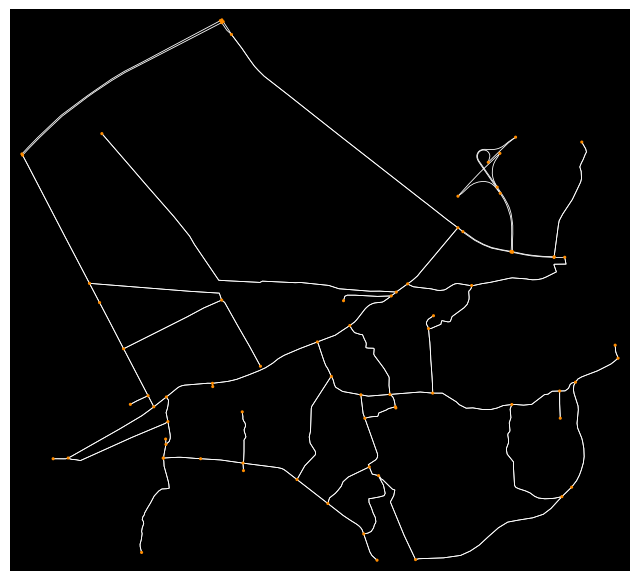

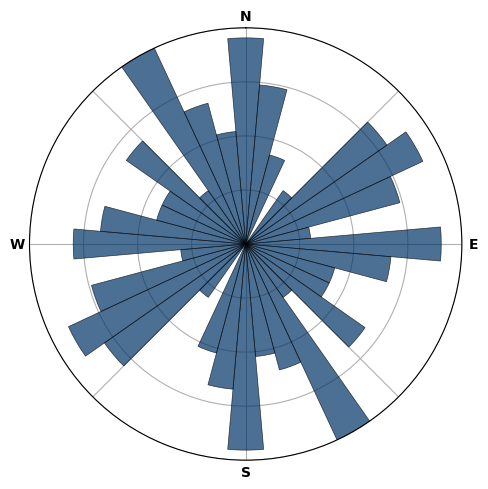

In [10]:
generate_styled_map("09", (32.165, 118.625), "Liuhe (Xiongzhou)", dist=3000)             # 六合雄州

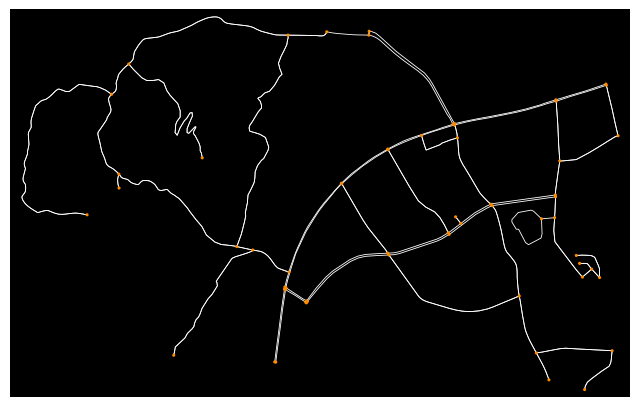

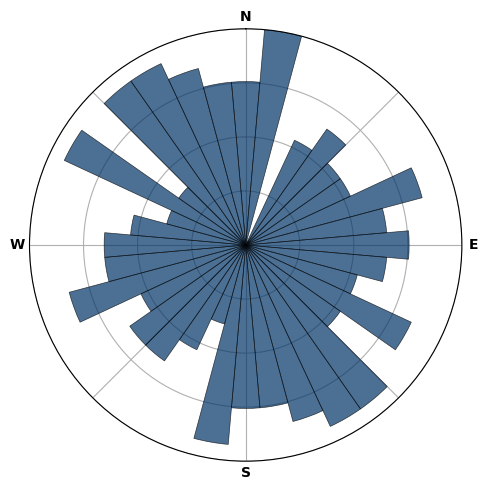

In [11]:
generate_styled_map("10", (32.085, 118.595), "Jiangbei New Area Core", dist=2500)        # 江北新区核心

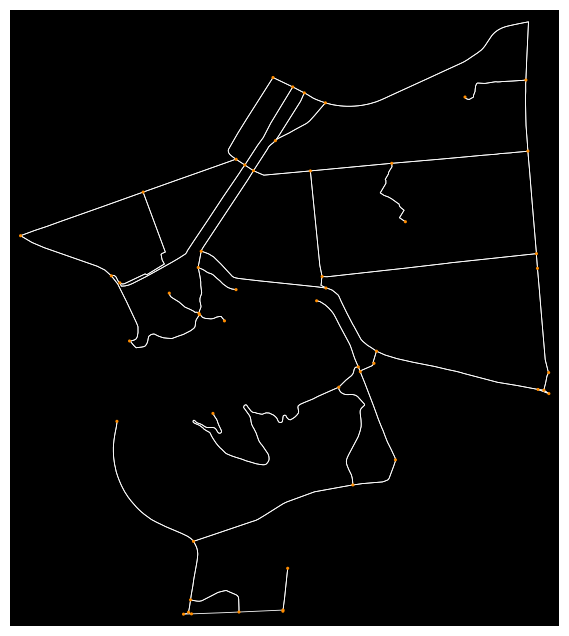

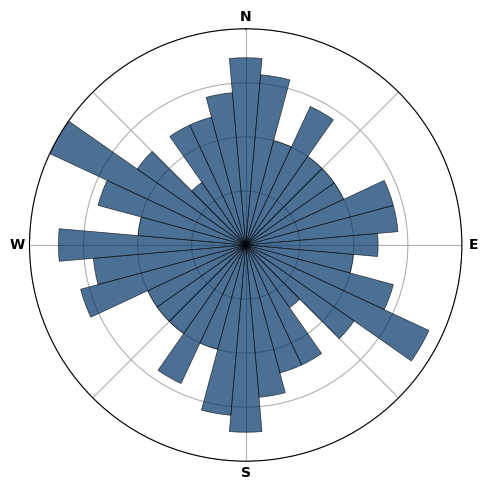

In [12]:
generate_styled_map("11", (31.865, 119.055), "Lishui (New City)", dist=3000)              # 溧水新城

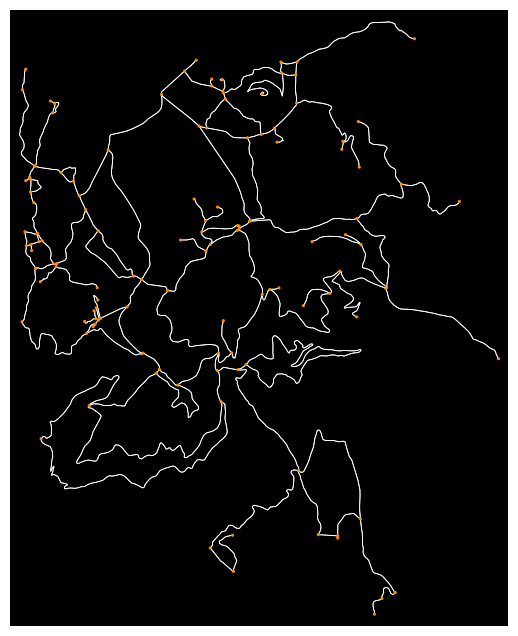

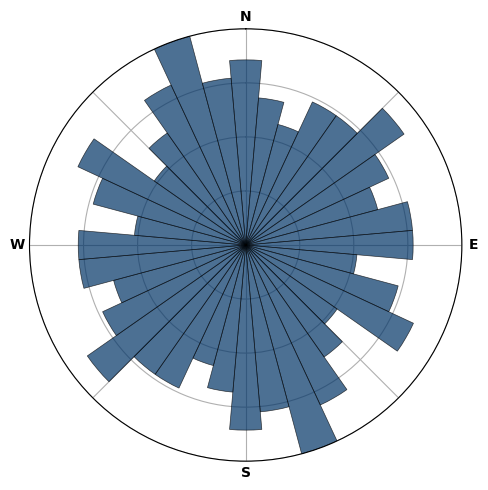

In [13]:
generate_styled_map("12", (31.635, 118.825), "Gaochun (Old Town)", dist=3000)            # 高淳老城

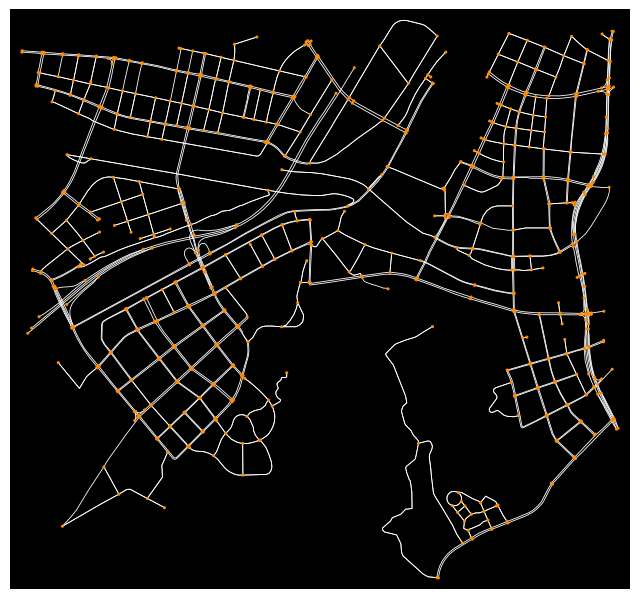

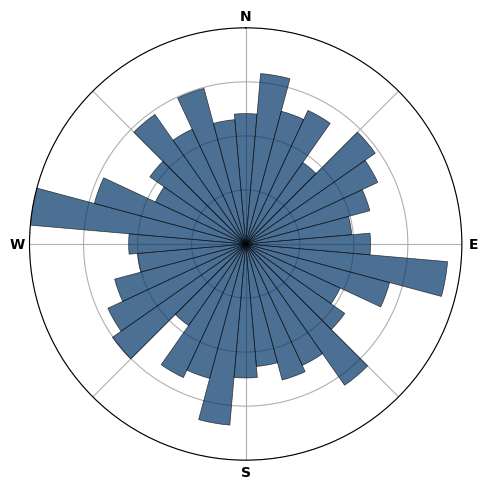

In [14]:
generate_styled_map("13", (31.945, 118.705), "South Airport Area", dist=3000)             # 南部机场片区

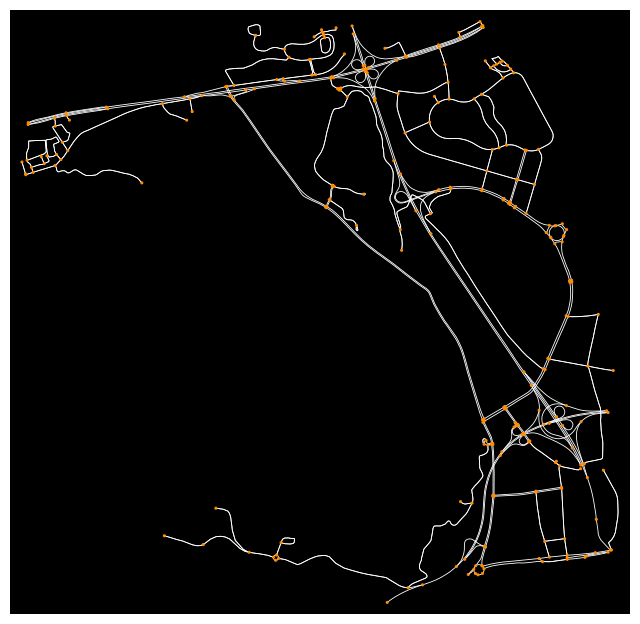

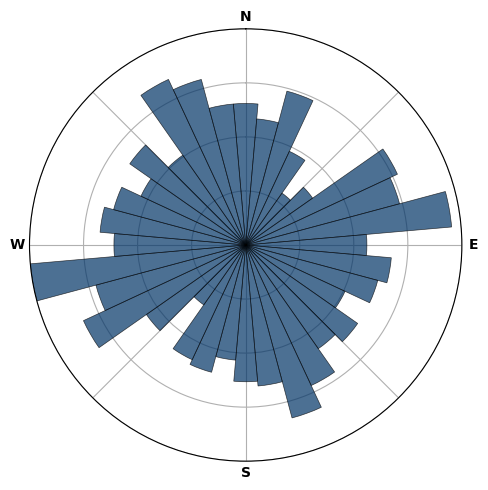

In [15]:
generate_styled_map("14", (32.075, 118.865), "East Xianlin Area", dist=3000)             # 仙林东部片区

In [19]:
print("\n" + "="*70)
print("NANJING CITY MORPHOLOGY: QUANTITATIVE SUMMARY")
print("="*70)

for label, d in city_data_vault.items():
    print(f"\n>> {label.upper()}")
    
    area = d.get('avg_area', 0)
    density = d.get('intersection_density', 0)
    nodes = d.get('nodes', 0)
    avg_degree = d.get('avg_degree', 0) 
    avg_length = d.get('avg_edge_length', 0)
    circuity = d.get('avg_circuity', 0)
    entropy = d.get('orientation_entropy', 0)
    centrality = d.get('avg_degree_centrality', 0)

    print(f"   Scale: {area:.2f} sq km | {nodes} nodes")
    print(f"   Connectivity: {density:.2f} int/km² | Centrality: {centrality:.4f}")
    print(f"   Complexity: {avg_length:.1f}m avg length | {circuity:.3f} circuity")
    
    if entropy < 3.0:
        morph = "Regular"
    elif entropy < 3.4:
        morph = "Semi-Regular"
    else:
        morph = "complex"
        
    print(f"   Orientation Entropy: {entropy:.4f} ({morph})")


NANJING CITY MORPHOLOGY: QUANTITATIVE SUMMARY

>> XUANWU (CITY CORE)
   Scale: 23.48 sq km | 0 nodes
   Connectivity: 30.07 int/km² | Centrality: 0.0064
   Complexity: 164.9m avg length | 1.027 circuity
   Orientation Entropy: 3.3092 (Semi-Regular)

>> QINHUAI (OLD TOWN)
   Scale: 23.81 sq km | 0 nodes
   Connectivity: 35.23 int/km² | Centrality: 0.0057
   Complexity: 161.6m avg length | 1.022 circuity
   Orientation Entropy: 3.1218 (Semi-Regular)

>> GULOU (BUSINESS CORE)
   Scale: 23.98 sq km | 0 nodes
   Connectivity: 31.23 int/km² | Centrality: 0.0056
   Complexity: 169.6m avg length | 1.024 circuity
   Orientation Entropy: 3.3667 (Semi-Regular)

>> JIANYE (HEXI CBD)
   Scale: 23.29 sq km | 0 nodes
   Connectivity: 32.93 int/km² | Centrality: 0.0051
   Complexity: 183.5m avg length | 1.031 circuity
   Orientation Entropy: 3.0812 (Semi-Regular)

>> YUHUATAI (TECH ZONE)
   Scale: 24.01 sq km | 0 nodes
   Connectivity: 26.33 int/km² | Centrality: 0.0063
   Complexity: 197.5m avg leng

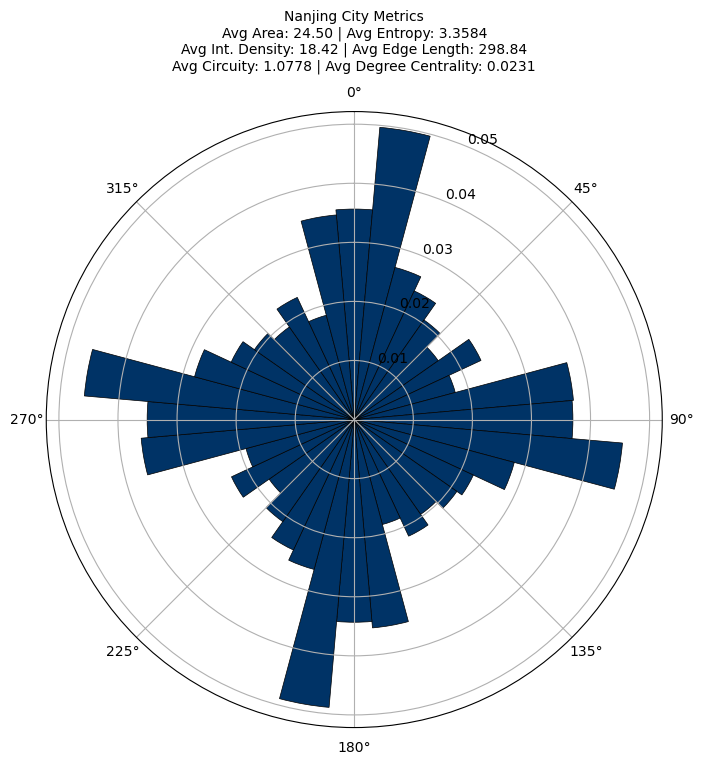

In [17]:
all_combined_bearings = []
collected_labels = []

metrics = {
    'area': [],
    'entropy': [],
    'int_density': [],
    'edge_length': [],
    'circuity': [],
    'centrality': []
}

for label, data in city_data_vault.items():
    if 'bearings' in data and data['bearings'] is not None:
        all_combined_bearings.extend(list(data['bearings']))
        collected_labels.append(label)
        
        metrics['area'].append(data.get('avg_area', 0))
        metrics['entropy'].append(data.get('orientation_entropy', 0))
        metrics['int_density'].append(data.get('intersection_density', 0))
        metrics['edge_length'].append(data.get('avg_edge_length', 0))
        metrics['circuity'].append(data.get('avg_circuity', 0))
        metrics['centrality'].append(data.get('avg_degree_centrality', 0))

if not all_combined_bearings:
    print("Error: No data collected from the dictionary.")
else:
    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}
    
    n = 36
    bins = np.arange(0, 360 + 360/n, 360/n)
    counts, _ = np.histogram(all_combined_bearings, bins=bins)
    proportions = counts / counts.sum()

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    ax.bar(np.radians(bins[:-1]), proportions, width=np.radians(360/n), 
           color='#003366', edgecolor='black', linewidth=0.5)

    stats_text = (
        f"Nanjing City Metrics\n"
        f"Avg Area: {avg_metrics['area']:.2f} | "
        f"Avg Entropy: {avg_metrics['entropy']:.4f}\n"
        f"Avg Int. Density: {avg_metrics['int_density']:.2f} | "
        f"Avg Edge Length: {avg_metrics['edge_length']:.2f}\n"
        f"Avg Circuity: {avg_metrics['circuity']:.4f} | "
        f"Avg Degree Centrality: {avg_metrics['centrality']:.4f}"
    )
    
    ax.set_title(stats_text, pad=30, fontsize=10)
    plt.show()